In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)

X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')

lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

print('All models trained successfully!')

All models trained successfully!


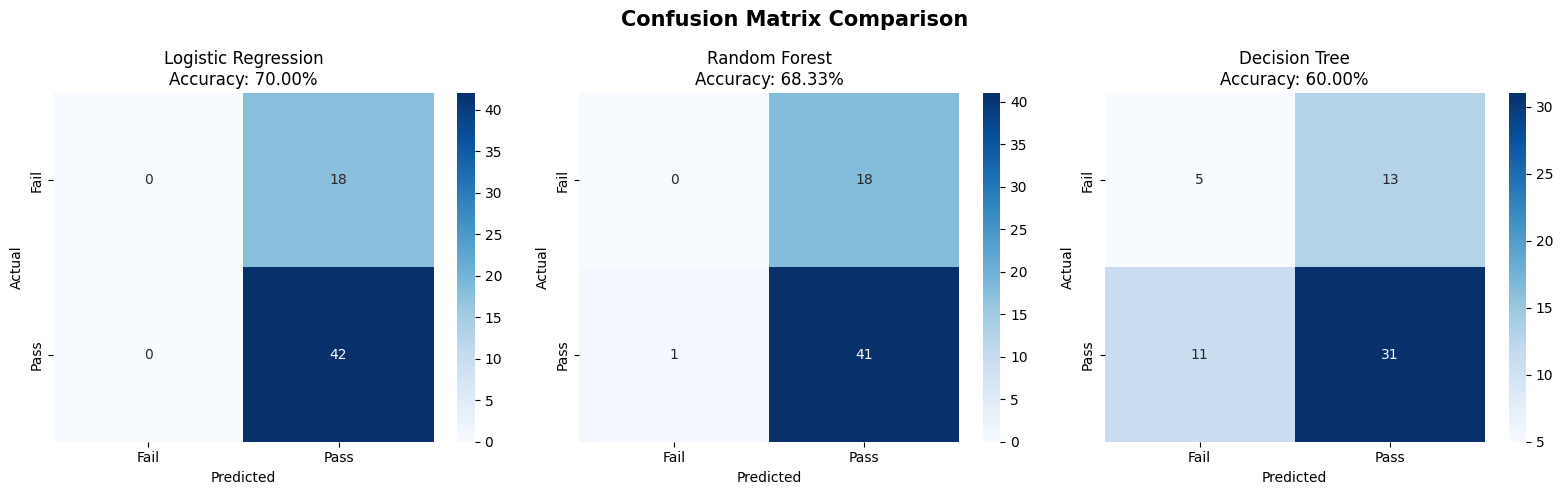

In [2]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')

models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'Decision Tree': dt_pred
}

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Fail', 'Pass'],
        yticklabels=['Fail', 'Pass']
    )
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred)*100:.2f}%')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

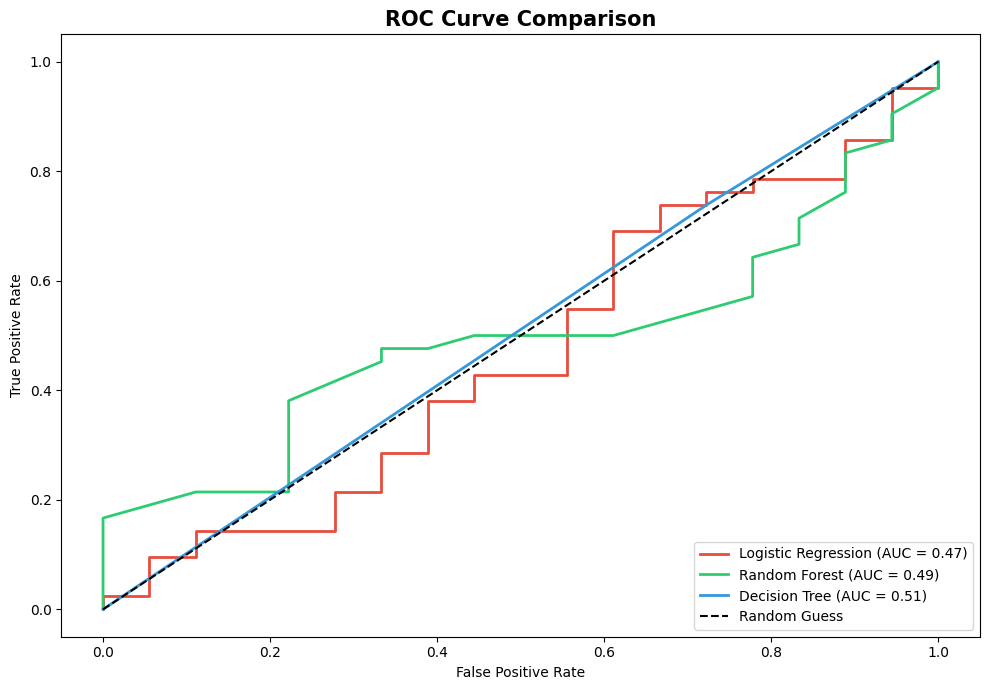

In [3]:

fig, ax = plt.subplots(figsize=(10, 7))

models_prob = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Decision Tree': dt_model
}

colors = ['#e74c3c', '#2ecc71', '#3498db']

for (name, model), color in zip(models_prob.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess')
ax.set_title('ROC Curve Comparison', fontsize=15, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [4]:

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred)*100,
        accuracy_score(y_test, rf_pred)*100,
        accuracy_score(y_test, dt_pred)*100
    ],
    'AUC Score': [
        auc(*roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])[:2]),
        auc(*roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])[:2]),
        auc(*roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])[:2])
    ]
})

results = results.sort_values('Accuracy', ascending=False)
print('=== Final Model Comparison ===')
print(results.to_string(index=False))
print(f'\n🏆 Best Model: {results.iloc[0]["Model"]}')
print(f'✅ Best Accuracy: {results.iloc[0]["Accuracy"]:.2f}%')
print(f'✅ Best AUC Score: {results.iloc[0]["AUC Score"]:.2f}')

=== Final Model Comparison ===
              Model  Accuracy  AUC Score
Logistic Regression 70.000000   0.466931
      Random Forest 68.333333   0.493386
      Decision Tree 60.000000   0.507937

🏆 Best Model: Logistic Regression
✅ Best Accuracy: 70.00%
✅ Best AUC Score: 0.47
